In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### Five features in eye movement dataset
A: Time spent on each face in the last 200ms of a trial.

B: Total time spent on each face throughout the trial.

C: Total gaze focus points on each face throughout the trial.

D: Interest sustainability represents how a subject’s interest
    in a face increases or decreases over the trial by considering
    the change in continuous time looking at a face and how
    much it increases or decreases over the trial.
    
E: egion change represents the amount of movement
    among the regions of a face. Consider the regions of a face
    as nodes in a graph and here we count the edges that
    represent movement between face regions.

## Data processing

In [3]:
# Load the dataset
df = pd.read_csv('../Face Image Preference/ScoreFunctions-withRating.csv')
df.shape

(720, 6)

In [4]:
df.head(5)

,A,B,C,D,E,Rating
0,0.0,0.460124,0.428571,0.468178,0.463415,Right
1,0.0,0.498609,0.571429,0.469353,0.512195,Right
2,1.0,0.535394,0.628571,0.385390,0.463415,Left
3,1.0,0.607883,0.828571,0.363728,0.585366,Left
4,1.0,0.551005,0.600000,0.398489,0.365854,Left


In [5]:
# map right to 0 and left to 1 for column Rating
df['Rating'] = df['Rating'].map({'Right': 0, 'Left': 1}) 
df.head(5)

,A,B,C,D,E,Rating
0,0.0,0.460124,0.428571,0.468178,0.463415,0
1,0.0,0.498609,0.571429,0.469353,0.512195,0
2,1.0,0.535394,0.628571,0.385390,0.463415,1
3,1.0,0.607883,0.828571,0.363728,0.585366,1
4,1.0,0.551005,0.600000,0.398489,0.365854,1


In [6]:
# get some basic statistics about the dataset
df.describe()

,A,B,C,D,E,Rating
count,720.000000,720.000000,720.000000,720.000000,720.000000,720.000000
mean,0.501889,0.511695,0.572698,0.360832,0.368869,0.495833
std,0.486127,0.103339,0.124017,0.099445,0.100773,0.500330
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.456839,0.514286,0.314652,0.317073,0.000000
50%,0.530000,0.514992,0.571429,0.357011,0.365854,0.000000
75%,1.000000,0.568083,0.628571,0.394794,0.414634,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [7]:
# calculate performance for each column using precision@k (k = 100, 200, 300)
def precision_at_k(df, columns, k):
    precisions = {}
    for column in columns:
        df_sorted = df.sort_values(by=column, ascending=False).reset_index(drop=True)
        prec = df_sorted['Rating'].head(k).sum() / k
        precisions[column] = prec
    return precisions

In [8]:
# feature A is stronger, D is the weakest
precision_at_k(df, ['A', 'B', 'C', 'D', 'E'], 100)

{'A': np.float64(0.87),
 'B': np.float64(0.83),
 'C': np.float64(0.78),
 'D': np.float64(0.51),
 'E': np.float64(0.73)}

In [18]:
precision_at_k(df, ['A', 'B', 'C', 'D', 'E'], 200)

{'A': np.float64(0.915),
 'B': np.float64(0.78),
 'C': np.float64(0.74),
 'D': np.float64(0.535),
 'E': np.float64(0.69)}

In [19]:
precision_at_k(df, ['A', 'B', 'C', 'D', 'E'], 300)

{'A': np.float64(0.9066666666666666),
 'B': np.float64(0.7466666666666667),
 'C': np.float64(0.7133333333333334),
 'D': np.float64(0.5033333333333333),
 'E': np.float64(0.6733333333333333)}

## CFA part

In [9]:
from cfa import cfa_single_layer, performance_plot, RSC_graph, compute_cd_ds, compute_performance

In [10]:
df1 = df[['A', 'B', 'C', 'D', 'E']]
df1.head(2)

,A,B,C,D,E
0,0.0,0.460124,0.428571,0.468178,0.463415
1,0.0,0.498609,0.571429,0.469353,0.512195


In [11]:
y_true = df['Rating'].values
y_true

array([0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0,
       0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0,
       0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1,
       0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1,
       0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0,
       1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0,
       1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1,
       1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0,

### rank-score funciton graph

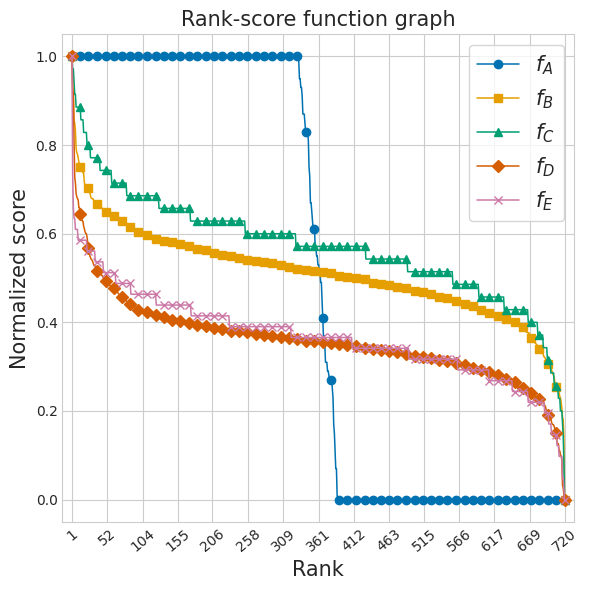

In [13]:
RSC_graph(df1)

### Precision at k=100

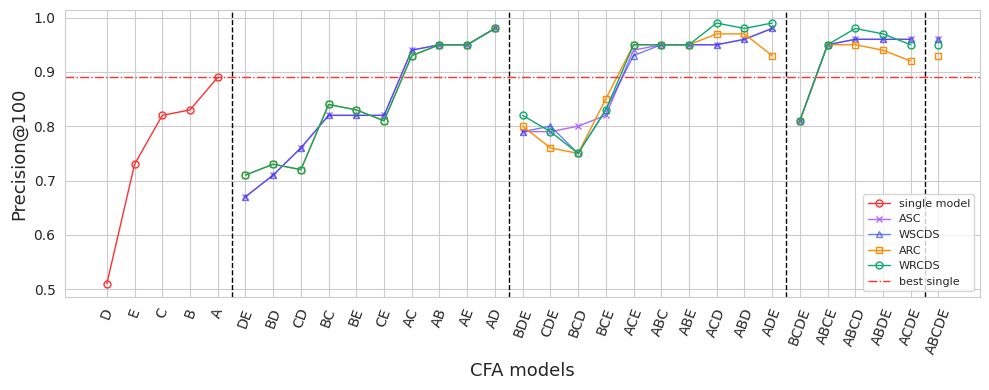

Best combination: 0.9900
Best single: 0.8900


In [14]:
perf = cfa_single_layer(df1, y_true, perf_metric='precision@k', k = 100)
fused_result = performance_plot(perf, ylabel="Precision@100")

In [15]:
perf

,asc,wscds,arc,wrcds
A,0.89,0.89,0.89,0.89
B,0.83,0.83,0.83,0.83
C,0.82,0.82,0.82,0.82
D,0.51,0.51,0.51,0.51
E,0.73,0.73,0.73,0.73
AB,0.95,0.95,0.95,0.95
AC,0.94,0.94,0.93,0.93
AD,0.98,0.98,0.98,0.98
AE,0.95,0.95,0.95,0.95
BC,0.82,0.82,0.84,0.84


### Precision at k = 200

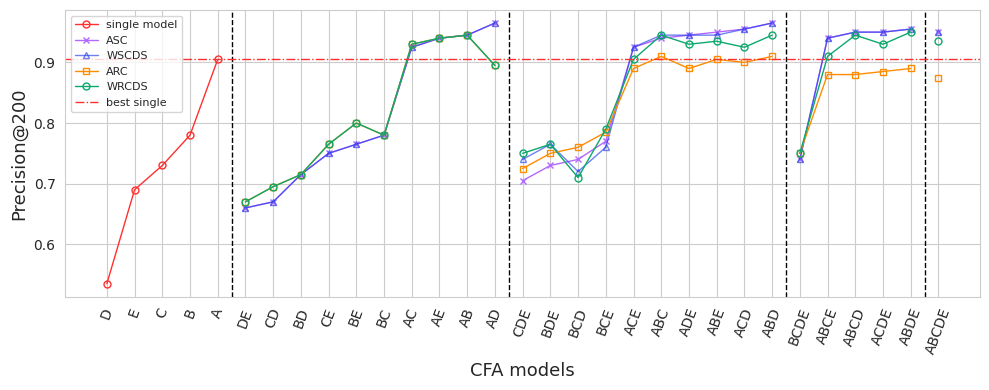

Best combination: 0.9650
Best single: 0.9050


In [22]:
perf = cfa_single_layer(df1, y_true, perf_metric='precision@k', k = 200)
fused_result = performance_plot(perf, ylabel="Precision@200")

### Precision at k = 300

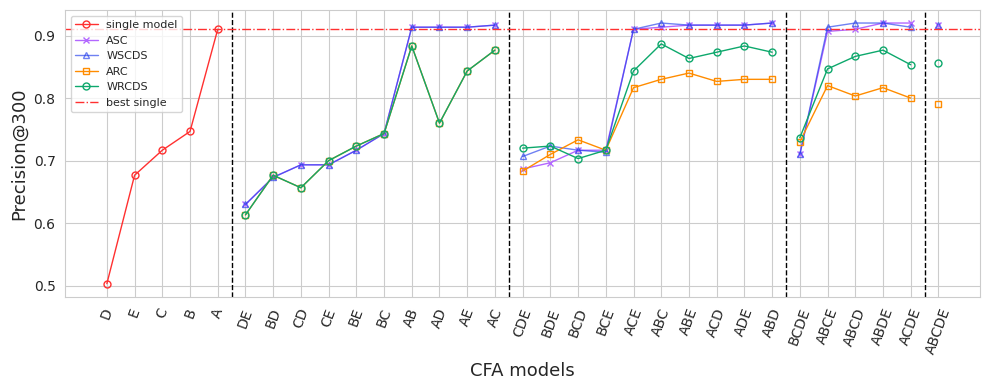

Best combination: 0.9200
Best single: 0.9100


In [23]:
perf = cfa_single_layer(df1, y_true, perf_metric='precision@k', k = 300)
fused_result = performance_plot(perf, ylabel="Precision@300")